In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
data = pd.read_csv('Trips_2018/Trips_2018.csv')

# Clustering

### Exploration

In [3]:
print(data.head())
print(data.columns.tolist())

# Get minimum start time and maximum end time
print(data['starttime'].min())
print(data['starttime'].max())

   Unnamed: 0  tripduration                 starttime  \
0           0           970  2018-01-01 13:50:57.4340   
1           1           723  2018-01-01 15:33:30.1820   
2           2           496  2018-01-01 15:39:18.3370   
3           3           306  2018-01-01 15:40:13.3720   
4           4           306  2018-01-01 18:14:51.5680   

                   stoptime  start_station_id  start_station_latitude  \
0  2018-01-01 14:07:08.1860              72.0               40.767272   
1  2018-01-01 15:45:33.3410              72.0               40.767272   
2  2018-01-01 15:47:35.1720              72.0               40.767272   
3  2018-01-01 15:45:20.1910              72.0               40.767272   
4  2018-01-01 18:19:57.6420              72.0               40.767272   

   start_station_longitude  end_station_id  end_station_latitude  \
0               -73.993929           505.0             40.749013   
1               -73.993929          3255.0             40.750585   
2             

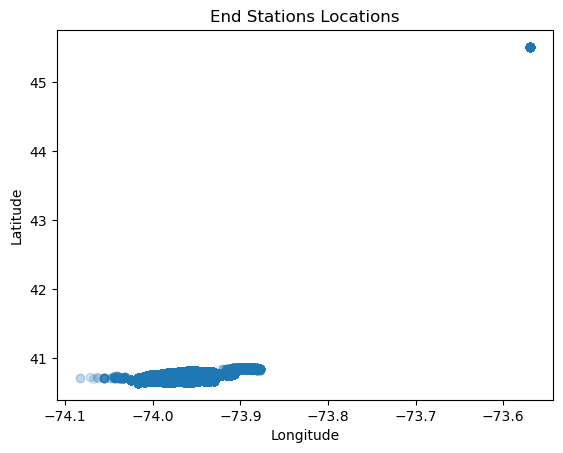

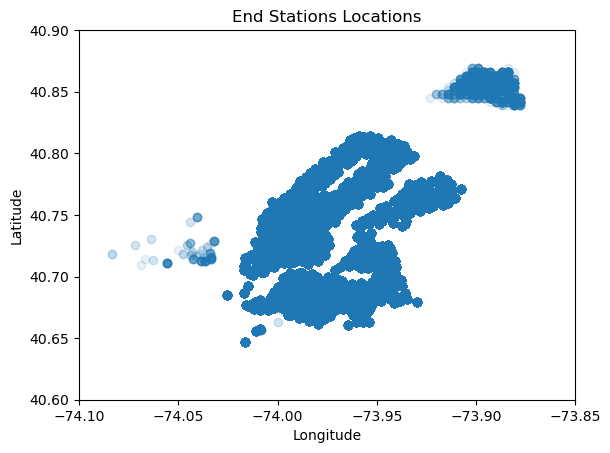

In [ ]:
'''
  We see that the dataset have some outliers
'''
plt.scatter(data['end_station_longitude'], data['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
# plt.xlim([-74.1, -73.85])
plt.show()

plt.scatter(data['end_station_longitude'], data['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
plt.xlim([-74.1, -73.85])
plt.ylim([40.6, 40.9])
plt.show()

import folium
m = folium.Map(location=[40.75, -73.97], zoom_start=12)
for lat, lon in zip(data['end_station_latitude'], data['end_station_longitude']):
    folium.CircleMarker(location=[lat, lon], radius=1, fill=True, fill_opacity=0.2).add_to(m)

m

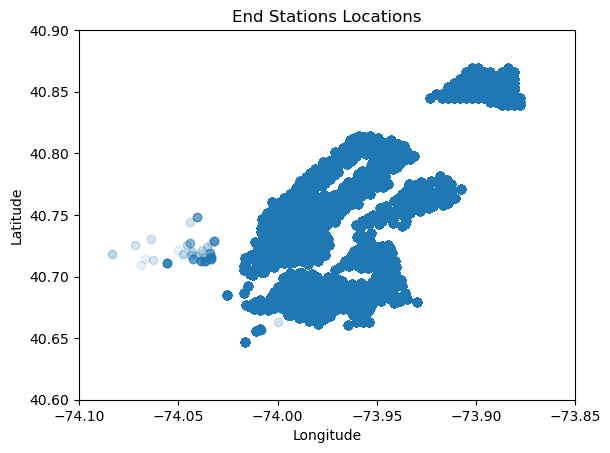

In [ ]:
plt.scatter(data['end_station_longitude'], data['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
plt.xlim([-74.1, -73.85])
plt.ylim([40.6, 40.9])
plt.show()

import folium
m = folium.Map(location=[40.75, -73.97], zoom_start=12)
for lat, lon in zip(data['end_station_latitude'], data['end_station_longitude']):
    folium.CircleMarker(location=[lat, lon], radius=1, fill=True, fill_opacity=0.2).add_to(m)

m

### Baseline model

In [ ]:
# Prepare data for k-means
# Extract station_id, latitude and longitude st. we get all stations in the model
stations_start = data[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
stations_start.columns = ['station_id', 'latitude', 'longitude']

stations_end = data[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
stations_end.columns = ['station_id', 'latitude', 'longitude']
stations = pd.concat([stations_start, stations_end]).drop_duplicates().reset_index(drop=True)

# Remove outlier, we should add it again after traning the model
print(stations[stations['latitude'] > 44]['station_id'].unique())
stations = stations[stations['latitude'] < 44]

[3488. 3650.]


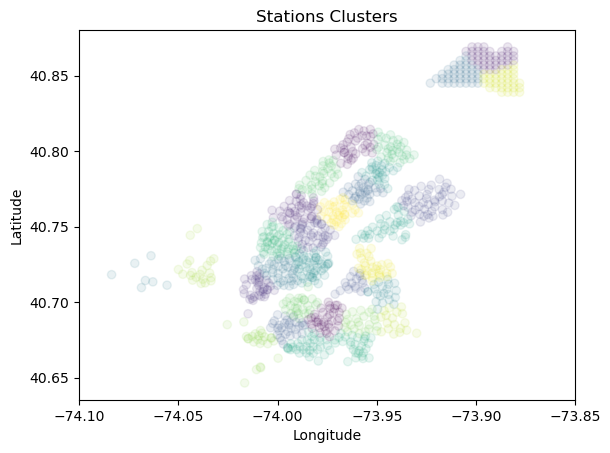

In [ ]:
kmeans = KMeans(n_clusters=30)
stations['station_cluster'] = kmeans.fit_predict(stations[['longitude', 'latitude']])
plt.scatter(stations['longitude'], stations['latitude'], c=stations['station_cluster'], cmap='viridis', alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Stations Clusters')
plt.xlim([-74.1, -73.85])
plt.show()

### Postprocessing

In [ ]:
# We add the clusters back to the dataframe based on where the journey start
data = data.merge(
    stations[['station_id', 'station_cluster']],
    how='left',
    left_on='start_station_id',
    right_on='station_id'
).rename(columns={'station_cluster': 'start_station_cluster'}).drop(columns=['station_id'])

# We get 47 nulls because we removed two outliers, we manually set it to the 30'th cluster st. we 31 in total
# Where startstation cluster = 3488 or 3650
print(data['start_station_cluster'].isnull().sum())
data.loc[data['start_station_id'] == 3488, 'start_station_cluster'] = stations['station_cluster'].max() + 1
data.loc[data['start_station_id'] == 3650, 'start_station_cluster'] = stations['station_cluster'].max() + 1
print(data['start_station_cluster'].isnull().sum())



81
0


In [ ]:
print(data.head())
print(data.columns.tolist())


   Unnamed: 0  tripduration                 starttime  \
0           0           970  2018-01-01 13:50:57.4340   
1           1           723  2018-01-01 15:33:30.1820   
2           2           496  2018-01-01 15:39:18.3370   
3           3           306  2018-01-01 15:40:13.3720   
4           4           306  2018-01-01 18:14:51.5680   

                   stoptime  start_station_id  start_station_latitude  \
0  2018-01-01 14:07:08.1860              72.0               40.767272   
1  2018-01-01 15:45:33.3410              72.0               40.767272   
2  2018-01-01 15:47:35.1720              72.0               40.767272   
3  2018-01-01 15:45:20.1910              72.0               40.767272   
4  2018-01-01 18:19:57.6420              72.0               40.767272   

   start_station_longitude  end_station_id  end_station_latitude  \
0               -73.993929           505.0             40.749013   
1               -73.993929          3255.0             40.750585   
2             

In [ ]:
# Based on the data dateframe plot the number of rows in each cluster